# iProperty Data Cleaning Pipeline
**Course:** High Performance Data Processing — Project 1  
**Dataset:** iProperty Malaysia — 100,000 property listings  
**Objective:** Clean, transform, and validate the raw scraped dataset for downstream analysis and optimization benchmarking.

## 0. Imports & Configuration

In [3]:
import pandas as pd
import numpy as np
import re
import time
import os
import matplotlib.pyplot as plt
from datetime import datetime

# ── Paths ────────────────────────────────────────────────────────────────────
# UPDATE these two lines to match where your files actually are.
# Option A — CSV is in the SAME folder as this notebook:
#   RAW_PATH = "iproperty_data.csv"
# Option B — full/relative path, e.g.:
#   RAW_PATH = r"C:\Users\piyat\Downloads\iproperty_data.csv"
#   RAW_PATH = "../data/iproperty_data.csv"
RAW_PATH     = r"C:\SEM6\HPDP\iproperty_scrape\data\iproperty_data.csv"   # <-- CHANGE THIS if the CSV is elsewhere
CLEANED_PATH = "iproperty_cleaned.csv"  # cleaned output will be saved here

# ── Display settings ─────────────────────────────────────────────────────────
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", "{:,.2f}".format)

print(f"Pandas version : {pd.__version__}")
print(f"NumPy  version : {np.__version__}")
print(f"Run timestamp  : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Pandas version : 3.0.3
NumPy  version : 2.4.6
Run timestamp  : 2026-05-30 22:35:22


## 1. Load Raw Data

In [4]:
t0 = time.time()

df_raw = pd.read_csv(RAW_PATH, low_memory=False)

print(f"✅ Loaded {len(df_raw):,} rows × {df_raw.shape[1]} columns  ({time.time()-t0:.2f}s)")
print(f"\nColumns: {df_raw.columns.tolist()}")
df_raw.head(3)

✅ Loaded 100,000 rows × 17 columns  (2.24s)

Columns: ['listing_id', 'listing_type', 'title', 'price', 'location', 'bedrooms', 'bathrooms', 'size_sqft', 'property_type', 'tenure', 'furnishing', 'car_parks', 'agent', 'listing_url', 'source_url', 'region', 'url_ptype']


,listing_id,listing_type,title,price,location,bedrooms,bathrooms,size_sqft,property_type,tenure,furnishing,car_parks,agent,listing_url,source_url,region,url_ptype
0,sale-501424485,for-sale,"𝐆𝐨𝐯 𝐬𝐮𝐛𝐬𝐢𝐝𝐲 𝐋𝐚𝐧𝐝𝐞𝐝 𝐑𝐌𝟑𝟒𝟎𝐤, 𝟓𝐦𝐢𝐧 𝐊𝐢𝐩 𝐌𝐚𝐥𝐥, 𝟎% 𝐃𝐨𝐰𝐧𝐩𝐚𝐲𝐦𝐞𝐧t...","RM 340,000RM 193.18 psf𝐆𝐨𝐯 𝐬𝐮𝐛𝐬𝐢𝐝𝐲 𝐋𝐚𝐧𝐝𝐞𝐝 𝐑𝐌𝟑𝟒𝟎𝐤, 𝟓𝐦𝐢𝐧 𝐊...","𝐆𝐨𝐯 𝐬𝐮𝐛𝐬𝐢𝐝𝐲 𝐋𝐚𝐧𝐝𝐞𝐝 𝐑𝐌𝟑𝟒𝟎𝐤, 𝟓𝐦𝐢𝐧 𝐊𝐢𝐩 𝐌𝐚𝐥𝐥, 𝟎% 𝐃𝐨𝐰𝐧𝐩𝐚𝐲𝐦𝐞𝐧t...",NaN,NaN,NaN,"𝐆𝐨𝐯 𝐬𝐮𝐛𝐬𝐢𝐝𝐲 𝐋𝐚𝐧𝐝𝐞𝐝 𝐑𝐌𝟑𝟒𝟎𝐤, 𝟓𝐦𝐢𝐧 𝐊𝐢𝐩 𝐌𝐚𝐥𝐥, 𝟎% 𝐃𝐨𝐰𝐧𝐩𝐚𝐲𝐦𝐞𝐧t...",NaN,Unfurnished,NaN,NaN,https://www.iproperty.com.my/property/sepang/gov-subsidy...,https://www.iproperty.com.my/property-for-sale/in-selang...,Selangor,NaN
1,sale-108390473,for-sale,"Taman Cempaka, Ampang","RM 850,000RM 607.14 psfTaman Cempaka, AmpangJalan Cempak...","Taman Cempaka, AmpangJalan Cempaka 3, Taman Cempaka, Amp...",NaN,NaN,NaN,"Taman Cempaka, Ampang",NaN,Partially Furnished,NaN,NaN,https://www.iproperty.com.my/property/ampang/taman-cempa...,https://www.iproperty.com.my/property-for-sale/in-selang...,Selangor,NaN
2,sale-104258945,for-sale,"TROPICANA, Tropicana","RM 5,800,000RM 644.44 psfTROPICANA, TropicanaTROPICANA G...","TROPICANA, TropicanaTROPICANA GOLF, TROPICANA, Tropicana...",NaN,NaN,NaN,"TROPICANA, Tropicana",NaN,Partially Furnished,NaN,NaN,https://www.iproperty.com.my/property/tropicana/tropican...,https://www.iproperty.com.my/property-for-sale/in-selang...,Selangor,NaN


## 2. Initial Profiling — Understand the Raw Data

In [5]:
# ── 2.1 Shape & dtypes ───────────────────────────────────────────────────────
print("=" * 60)
print(f"Rows    : {df_raw.shape[0]:,}")
print(f"Columns : {df_raw.shape[1]}")
print("=" * 60)
print(df_raw.dtypes)

Rows    : 100,000
Columns : 17
listing_id           str
listing_type         str
title                str
price                str
location             str
bedrooms         float64
bathrooms        float64
size_sqft        float64
property_type        str
tenure               str
furnishing           str
car_parks        float64
agent                str
listing_url          str
source_url           str
region               str
url_ptype            str
dtype: object


In [6]:
# ── 2.2 Missing value summary ─────────────────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_%", ascending=False)
print("Columns with missing values:")
print(missing_df.to_string())

Columns with missing values:
            missing_count  missing_%
bedrooms           100000     100.00
bathrooms          100000     100.00
size_sqft          100000     100.00
car_parks           99960      99.96
agent               99544      99.54
tenure              97414      97.41
url_ptype           86990      86.99
furnishing           4402       4.40


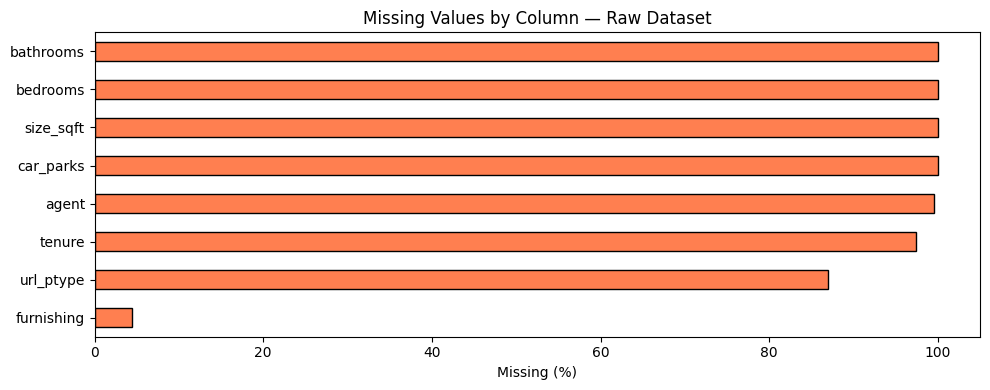

Figure saved: missing_values_raw.png


In [7]:
# ── 2.3 Visualise missingness ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
missing_df["missing_%"].sort_values().plot(
    kind="barh", color="coral", edgecolor="black", ax=ax
)
ax.set_xlabel("Missing (%)")
ax.set_title("Missing Values by Column — Raw Dataset")
plt.tight_layout()
plt.savefig("missing_values_raw.png", dpi=120)
plt.show()
print("Figure saved: missing_values_raw.png")

In [8]:
# ── 2.4 Duplicate check ───────────────────────────────────────────────────────
full_dups   = df_raw.duplicated().sum()
id_dups     = df_raw["listing_id"].duplicated().sum()
print(f"Full-row duplicates  : {full_dups:,}")
print(f"listing_id duplicates: {id_dups:,}")

Full-row duplicates  : 0
listing_id duplicates: 0


## 3. Cleaning Step-by-Step

We work on a **copy** of the raw dataframe so the original is never mutated.

In [9]:
df = df_raw.copy()
cleaning_log = {}   # track rows removed / transformed at each step

### 3.1 Remove Duplicate Rows

In [10]:
before = len(df)

# Drop full-row duplicates first
df.drop_duplicates(inplace=True)

# Then drop any remaining listing_id duplicates (keep first occurrence)
df.drop_duplicates(subset=["listing_id"], keep="first", inplace=True)
df.reset_index(drop=True, inplace=True)

removed = before - len(df)
cleaning_log["3.1 Duplicate removal"] = removed
print(f"Rows before : {before:,}")
print(f"Rows removed: {removed:,}")
print(f"Rows after  : {len(df):,}")

Rows before : 100,000
Rows removed: 0
Rows after  : 100,000


### 3.2 Drop Columns That Cannot Be Recovered

In [11]:
# bedrooms, bathrooms, size_sqft, car_parks are 100% null in the raw file.
# We will RE-EXTRACT these from the 'price' field (which contains concatenated
# listing data scraped from the card text) in the next steps.
# url_ptype contains a cleaned property category for ~13% of rows — we keep it
# as a supplementary field and rename it.

# Drop source_url (crawler internal metadata, not useful for analysis)
cols_to_drop = ["source_url"]      # extend if needed
df.drop(columns=cols_to_drop, inplace=True, errors="ignore")

# Rename url_ptype → property_category  (cleaner semantic name)
df.rename(columns={"url_ptype": "property_category"}, inplace=True)

print(f"Remaining columns ({len(df.columns)}): {df.columns.tolist()}")

Remaining columns (16): ['listing_id', 'listing_type', 'title', 'price', 'location', 'bedrooms', 'bathrooms', 'size_sqft', 'property_type', 'tenure', 'furnishing', 'car_parks', 'agent', 'listing_url', 'region', 'property_category']


### 3.3 Extract Structured Fields from the `price` Column

The raw scraper concatenated several values into the `price` field:  
`RM 850,000 RM 607.14 psf <title> <full address> <beds><baths><car_parks>`

We parse out:
- `price_rm` — asking price in RM (numeric)
- `price_psf` — price per sq ft (numeric)
- `size_sqft_derived` — estimated size = price ÷ psf
- `beds_derived`, `baths_derived`, `cars_derived` — trailing digit pattern

In [12]:
def extract_price_rm(raw: str) -> float | None:
    """Return the first RM XXX,XXX value (asking price)."""
    if not isinstance(raw, str):
        return None
    if re.search(r'contact\s+for\s+price', raw, re.I):
        return None
    # Handle price ranges — take the lower bound
    m = re.search(r'RM\s*([\d,]+)', raw, re.I)
    if m:
        try:
            return float(m.group(1).replace(",", ""))
        except ValueError:
            return None
    return None


def extract_psf(raw: str) -> float | None:
    """Return the price-per-sqft value."""
    if not isinstance(raw, str):
        return None
    m = re.search(r'RM\s*([\d,]+\.?\d*)\s*psf', raw, re.I)
    if m:
        try:
            return float(m.group(1).replace(",", ""))
        except ValueError:
            return None
    return None


def derive_sqft(price: float | None, psf: float | None) -> float | None:
    """Estimate size from price ÷ psf."""
    if price and psf and psf > 0:
        return round(price / psf)
    return None


def extract_trailing_rooms(raw: str):
    """Return (beds, baths, car_parks) parsed from trailing digits.
    iProperty cards end with e.g. '432' = 4 beds / 3 baths / 2 car parks.
    Also handles patterns like '5+14' = 5+1 beds / 4 car parks.
    Returns (None, None, None) when pattern is absent.
    """
    if not isinstance(raw, str):
        return None, None, None
    # Pattern: <beds+bonus>baths cars  e.g. "5+14" → beds=5, baths=1, cars=4
    m = re.search(r'(\d+)\+(\d)(\d)$', raw.strip())
    if m:
        return int(m.group(1)), int(m.group(2)), int(m.group(3))
    # Pattern: three single digits  e.g. "432"
    m2 = re.search(r'(\d)(\d)(\d)$', raw.strip())
    if m2:
        return int(m2.group(1)), int(m2.group(2)), int(m2.group(3))
    return None, None, None


# Apply extractions
df["price_rm"]          = df["price"].apply(extract_price_rm)
df["price_psf"]         = df["price"].apply(extract_psf)
df["size_sqft"]         = df.apply(lambda r: derive_sqft(r["price_rm"], r["price_psf"]), axis=1)

rooms = df["price"].apply(extract_trailing_rooms)
df["bedrooms"]   = rooms.apply(lambda x: x[0])
df["bathrooms"]  = rooms.apply(lambda x: x[1])
df["car_parks"]  = rooms.apply(lambda x: x[2])

# Drop the now-redundant raw price column (keep price_rm as the clean version)
df.drop(columns=["price"], inplace=True)

print("Extracted field summary:")
for col in ["price_rm", "price_psf", "size_sqft", "bedrooms", "bathrooms", "car_parks"]:
    filled = df[col].notna().sum()
    print(f"  {col:<20}: {filled:>7,} filled  ({filled/len(df)*100:.1f}%)")

Extracted field summary:
  price_rm            :  99,970 filled  (100.0%)
  price_psf           :  99,037 filled  (99.0%)
  size_sqft           :  99,029 filled  (99.0%)
  bedrooms            :  66,327 filled  (66.3%)
  bathrooms           :  66,327 filled  (66.3%)
  car_parks           :  66,327 filled  (66.3%)


### 3.4 Clean Text Fields

In [13]:
def clean_text(val) -> str | None:
    """Strip whitespace, remove non-ASCII, clean up leftover punctuation garbage."""
    if not isinstance(val, str):
        return None
    val = val.strip()
    val = re.sub(r'[^\x00-\x7F]+', ' ', val)  # remove non-ASCII (emoji, bold-font glyphs)
    val = re.sub(r'\s+', ' ', val)             # collapse multiple spaces
    # Remove lines that are pure punctuation/symbol garbage (e.g. ', , % t,')
    # A 'clean' value should contain at least one letter or digit
    if not re.search(r'[A-Za-z0-9]', val):
        return None
    val = val.strip()
    return val if val else None


text_cols = ["listing_id", "listing_type", "title", "location",
             "property_type", "furnishing", "agent", "region"]

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_text)

print("Text columns cleaned.")
df[["title", "location", "region"]].head(3)

Text columns cleaned.


,title,location,region
0,", , % t, Sepang",", , % t, SepangSepang, Selangor",Selangor
1,"Taman Cempaka, Ampang","Taman Cempaka, AmpangJalan Cempaka 3, Taman Cempaka, Amp...",Selangor
2,"TROPICANA, Tropicana","TROPICANA, TropicanaTROPICANA GOLF, TROPICANA, Tropicana...",Selangor


### 3.5 Standardise Categorical Fields

In [14]:
# ── listing_type ─────────────────────────────────────────────────────────────
df["listing_type"] = df["listing_type"].str.lower().str.strip()
valid_types = {"for-sale", "for-rent"}
df.loc[~df["listing_type"].isin(valid_types), "listing_type"] = None
print("listing_type:\n", df["listing_type"].value_counts(dropna=False))
print()

listing_type:
 listing_type
for-sale    64173
for-rent    35827
Name: count, dtype: int64



In [15]:
# ── furnishing ───────────────────────────────────────────────────────────────
furnishing_map = {
    "unfurnished"        : "Unfurnished",
    "partially furnished": "Partially Furnished",
    "fully furnished"    : "Fully Furnished",
}
df["furnishing"] = (
    df["furnishing"]
    .str.strip()
    .str.lower()
    .map(furnishing_map)
)
print("furnishing:\n", df["furnishing"].value_counts(dropna=False))
print()

furnishing:
 furnishing
Partially Furnished    39011
Fully Furnished        37387
Unfurnished            19200
NaN                     4402
Name: count, dtype: int64



In [16]:
# ── tenure ───────────────────────────────────────────────────────────────────
# 'Soho' appears in tenure; it is a property subtype — reclassify as NaN
valid_tenure = {"Freehold", "Leasehold"}
df.loc[~df["tenure"].isin(valid_tenure), "tenure"] = None
print("tenure:\n", df["tenure"].value_counts(dropna=False))
print()

tenure:
 tenure
NaN          98876
Freehold      1110
Leasehold       14
Name: count, dtype: int64



In [17]:
# ── property_category (from url_ptype) ───────────────────────────────────────
# Standardise hyphenated slugs to Title Case
df["property_category"] = (
    df["property_category"]
    .fillna("Unknown")
    .astype(str)
    .apply(lambda x: x.replace("-", " ").title() if x != "nan" else None)
)
# Remaining NaN from conversion
df.loc[df["property_category"] == "None", "property_category"] = None
df.loc[df["property_category"] == "Nan",  "property_category"] = None
print("property_category top-10:\n", df["property_category"].value_counts(dropna=False).head(12))

property_category top-10:
 property_category
Unknown                86990
Terrace House           3094
Apartment               2379
Flat                    2180
Bungalow                2034
Townhouse               1910
Semi Detached House     1117
Serviced Residence       201
Condominium               95
Name: count, dtype: int64


### 3.6 Handle Missing Values

In [18]:
# ── Numeric cols: cap extreme outliers then leave NaN (do NOT impute blindly) ─
# Reasonable bounds for Malaysian property:
#   price_rm   : 10,000 – 100,000,000
#   price_psf  : 10 – 10,000
#   size_sqft  : 100 – 100,000
#   bedrooms   : 0 – 20
#   bathrooms  : 0 – 20
#   car_parks  : 0 – 10

bounds = {
    "price_rm" : (10_000, 100_000_000),
    "price_psf": (10,     10_000),
    "size_sqft": (100,    100_000),
    "bedrooms" : (0,      20),
    "bathrooms": (0,      20),
    "car_parks": (0,      10),
}

for col, (lo, hi) in bounds.items():
    if col not in df.columns:
        continue
    before_out = df[col].notna().sum()
    # Replace out-of-range with NaN
    df.loc[(df[col] < lo) | (df[col] > hi), col] = np.nan
    after_out = df[col].notna().sum()
    print(f"  {col:<15}: {before_out - after_out:>5} outliers nullified")

print()
print("price_rm stats after outlier removal:")
print(df["price_rm"].describe())

  price_rm       : 33304 outliers nullified
  price_psf      : 34728 outliers nullified
  size_sqft      :   381 outliers nullified
  bedrooms       :     0 outliers nullified
  bathrooms      :     0 outliers nullified
  car_parks      :     0 outliers nullified

price_rm stats after outlier removal:
count       66,666.00
mean     1,475,686.59
std      2,567,136.05
min         10,000.00
25%        380,000.00
50%        698,000.00
75%      1,605,750.00
max     98,000,000.00
Name: price_rm, dtype: float64


In [19]:
# ── Categorical / text missing-value labelling ────────────────────────────────
# For reporting, fill remaining NaN with 'Unknown' only for categoricals
# (do not impute numeric columns)

cat_fill = {
    "furnishing"      : "Unknown",
    "tenure"          : "Unknown",
    "property_category": "Unknown",
    "agent"           : "Not Listed",
}
for col, fill in cat_fill.items():
    if col in df.columns:
        df[col].fillna(fill, inplace=True)

print("Categorical NaNs filled.")

Categorical NaNs filled.


C:\Users\piyat\AppData\Local\Temp\ipykernel_33148\818564062.py:13: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(fill, inplace=True)


### 3.7 Remove Rows with Critically Missing Core Fields

In [20]:
before = len(df)

# A listing must have at minimum: a valid listing_id, a title, a location, and a region.
core_required = ["listing_id", "title", "location", "region"]
df.dropna(subset=core_required, how="all", inplace=True)

# Drop rows where title is None/NaN (was entirely non-ASCII garbage e.g. bold-font ad text)
df.dropna(subset=["title"], inplace=True)

# Also drop rows where listing_id is empty string
df = df[df["listing_id"].str.strip().str.len() > 0]
df.reset_index(drop=True, inplace=True)

removed = before - len(df)
cleaning_log["3.7 Core-field null removal"] = removed
print(f"Removed {removed:,} rows missing all core fields.")
print(f"Remaining rows: {len(df):,}")

Removed 0 rows missing all core fields.
Remaining rows: 100,000


### 3.8 Normalise `region` — Fix Inconsistent Area Names

In [21]:
# The scraper captured some granular sub-areas (e.g., 'Petaling Jaya', 'Shah Alam')
# as separate regions instead of under 'Selangor'. We consolidate these into
# their parent state so region is a consistent state-level column.

SELANGOR_AREAS = {
    "Petaling Jaya", "Shah Alam", "Kajang", "Klang", "Subang Jaya",
    "Sungai Besi", "Batu Caves", "Ss2", "Ss1", "Ulu Kelang",
    "Seksyen 13", "Seksyen 11", "Bandar Baru Klang",
    "Bandar Utama Damansara", "Seksyen 24",
}
KL_AREAS = {"Kl Sentral", "Mont Kiara"}

def normalise_region(r):
    if r in SELANGOR_AREAS:
        return "Selangor"
    if r in KL_AREAS:
        return "Kuala Lumpur"
    return r

df["region"] = df["region"].apply(normalise_region)

print("Normalised region value counts:")
print(df["region"].value_counts())

Normalised region value counts:
region
Selangor           39293
Kuala Lumpur       15490
Johor              14809
Penang             11533
Melaka              3532
Negeri Sembilan     3468
Perak               3126
Sarawak             2977
Sabah               1954
Pahang              1924
Kedah               1361
Kelantan             327
Terengganu           188
Perlis                14
Labuan                 4
Name: count, dtype: int64


### 3.9 Final Data Type Assignment

In [22]:
# Convert numeric columns to the most efficient dtype
int_cols   = ["bedrooms", "bathrooms", "car_parks"]
float_cols = ["price_rm", "price_psf", "size_sqft"]

for col in int_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")  # nullable int

for col in float_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype(float)

# Categoricals
cat_cols = ["listing_type", "furnishing", "tenure", "region", "property_category"]
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

print("Final dtypes:")
print(df.dtypes)

Final dtypes:
listing_id                str
listing_type         category
title                     str
location                  str
bedrooms                Int64
bathrooms               Int64
size_sqft             float64
property_type             str
tenure               category
furnishing           category
car_parks               Int64
agent                     str
listing_url               str
region               category
property_category    category
price_rm              float64
price_psf             float64
dtype: object


### 3.10 Reorder Columns for Clarity

In [23]:
desired_order = [
    "listing_id",
    "listing_type",
    "title",
    "location",
    "region",
    "price_rm",
    "price_psf",
    "size_sqft",
    "bedrooms",
    "bathrooms",
    "car_parks",
    "property_type",
    "property_category",
    "tenure",
    "furnishing",
    "agent",
    "listing_url",
]

# Only keep columns that actually exist
final_cols = [c for c in desired_order if c in df.columns]
df = df[final_cols]

print(f"Final column order ({len(final_cols)}): {final_cols}")

Final column order (17): ['listing_id', 'listing_type', 'title', 'location', 'region', 'price_rm', 'price_psf', 'size_sqft', 'bedrooms', 'bathrooms', 'car_parks', 'property_type', 'property_category', 'tenure', 'furnishing', 'agent', 'listing_url']


## 4. Cleaning Summary

In [24]:
print("=" * 55)
print("  CLEANING SUMMARY")
print("=" * 55)
print(f"  Raw rows     : {len(df_raw):>8,}")
total_removed = sum(cleaning_log.values())
for step, n in cleaning_log.items():
    print(f"  {step:<35}: {n:>6,} removed")
print(f"  {'Total removed':<35}: {total_removed:>6,}")
print(f"  {'Final rows':<35}: {len(df):>6,}")
print("=" * 55)

  CLEANING SUMMARY
  Raw rows     :  100,000
  3.1 Duplicate removal              :      0 removed
  3.7 Core-field null removal        :      0 removed
  Total removed                      :      0
  Final rows                         : 100,000


In [25]:
# Post-cleaning missingness report
missing_after = df.isnull().sum()
missing_pct_after = (missing_after / len(df) * 100).round(2)
summary = pd.DataFrame({
    "missing_count": missing_after,
    "missing_%"    : missing_pct_after
}).sort_values("missing_%", ascending=False)
print("Missing values after cleaning:")
print(summary.to_string())

Missing values after cleaning:
                   missing_count  missing_%
agent                      99544      99.54
tenure                     98876      98.88
price_psf                  35691      35.69
car_parks                  33673      33.67
bedrooms                   33673      33.67
bathrooms                  33673      33.67
price_rm                   33334      33.33
furnishing                  4402       4.40
size_sqft                   1352       1.35
listing_id                     0       0.00
title                          0       0.00
location                       0       0.00
region                         0       0.00
listing_type                   0       0.00
property_type                  0       0.00
property_category              0       0.00
listing_url                    0       0.00


## 5. Exploratory Data Analysis (Post-Cleaning)

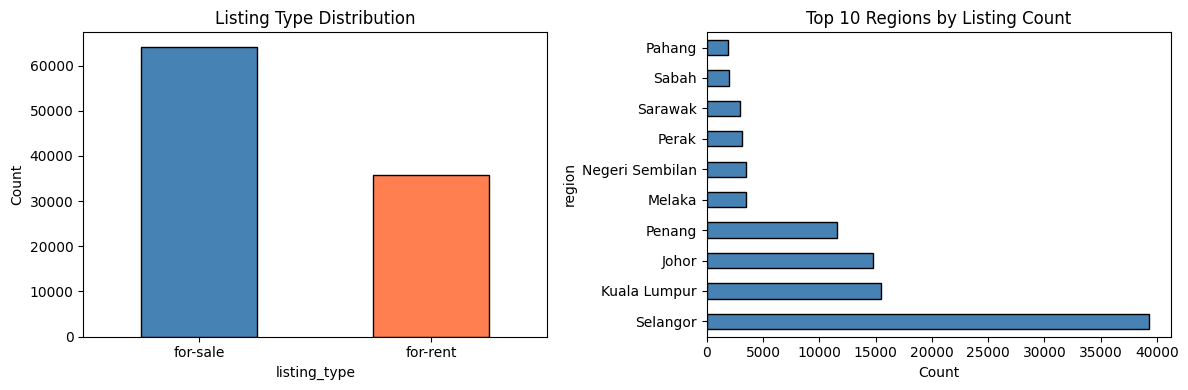

In [26]:
# ── 5.1 Listing type distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["listing_type"].value_counts().plot(
    kind="bar", ax=axes[0], color=["steelblue", "coral"], edgecolor="black"
)
axes[0].set_title("Listing Type Distribution")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

df["region"].value_counts().head(10).plot(
    kind="barh", ax=axes[1], color="steelblue", edgecolor="black"
)
axes[1].set_title("Top 10 Regions by Listing Count")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.savefig("eda_listing_region.png", dpi=120)
plt.show()

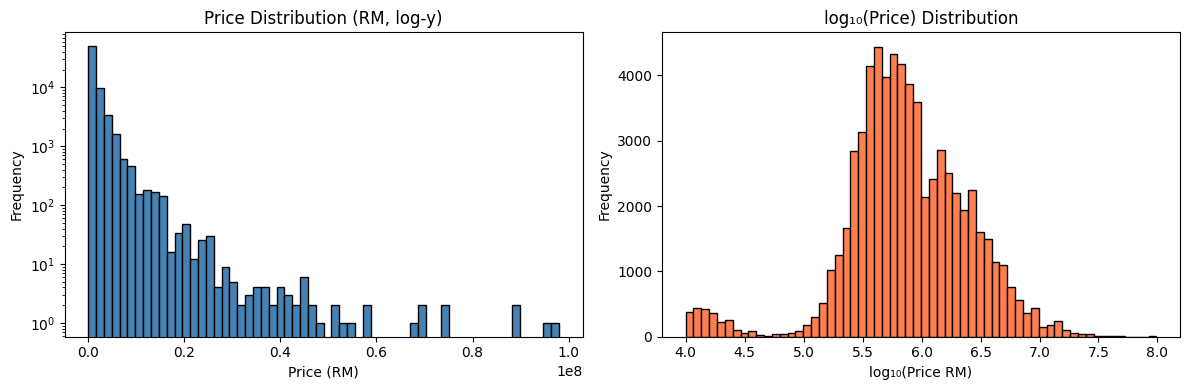

Descriptive statistics — price_rm:
count       66,666.00
mean     1,475,686.59
std      2,567,136.05
min         10,000.00
25%        380,000.00
50%        698,000.00
75%      1,605,750.00
max     98,000,000.00


In [27]:
# ── 5.2 Price distribution (log scale) ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

prices = df["price_rm"].dropna()
prices.plot(kind="hist", bins=60, ax=axes[0], color="steelblue", edgecolor="black", log=True)
axes[0].set_title("Price Distribution (RM, log-y)")
axes[0].set_xlabel("Price (RM)")

np.log10(prices).plot(
    kind="hist", bins=60, ax=axes[1], color="coral", edgecolor="black"
)
axes[1].set_title("log₁₀(Price) Distribution")
axes[1].set_xlabel("log₁₀(Price RM)")

plt.tight_layout()
plt.savefig("eda_price_distribution.png", dpi=120)
plt.show()

print("Descriptive statistics — price_rm:")
print(df["price_rm"].describe().to_string())

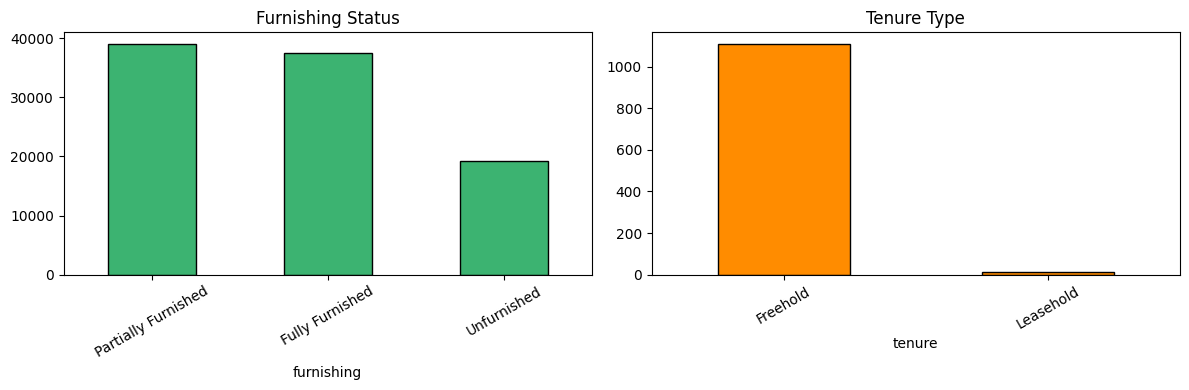

In [28]:
# ── 5.3 Furnishing & tenure breakdown ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["furnishing"].value_counts().plot(
    kind="bar", ax=axes[0], color="mediumseagreen", edgecolor="black"
)
axes[0].set_title("Furnishing Status")
axes[0].tick_params(axis="x", rotation=30)

df["tenure"].value_counts().plot(
    kind="bar", ax=axes[1], color="darkorange", edgecolor="black"
)
axes[1].set_title("Tenure Type")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("eda_furnishing_tenure.png", dpi=120)
plt.show()

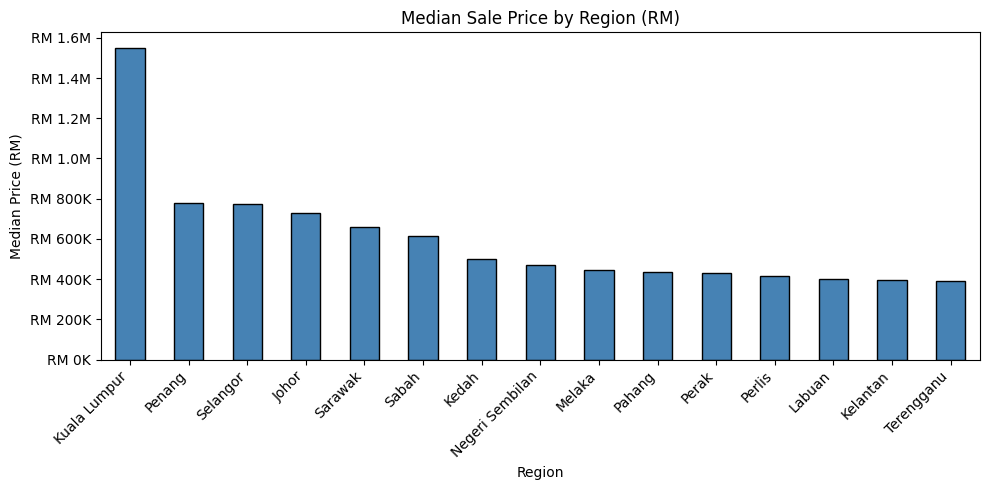

In [29]:
# ── 5.4 Median price by region (for-sale only) ────────────────────────────────
for_sale = df[df["listing_type"] == "for-sale"]

median_price = (
    for_sale.groupby("region", observed=True)["price_rm"]
    .median()
    .dropna()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
median_price.plot(kind="bar", color="steelblue", edgecolor="black", ax=ax)
ax.set_title("Median Sale Price by Region (RM)")
ax.set_ylabel("Median Price (RM)")
ax.set_xlabel("Region")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"RM {x/1e6:.1f}M" if x >= 1e6 else f"RM {x/1e3:.0f}K")
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("eda_median_price_by_region.png", dpi=120)
plt.show()

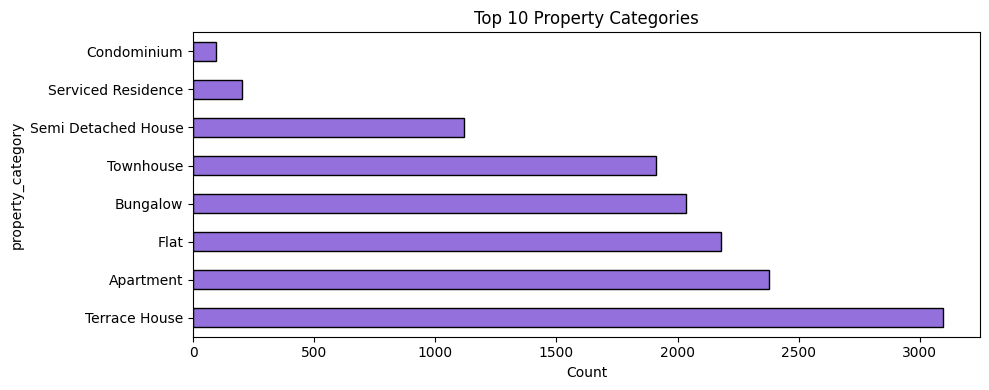

In [30]:
# ── 5.5 Property category breakdown ──────────────────────────────────────────
cat_counts = df["property_category"].value_counts().drop("Unknown", errors="ignore").head(10)

fig, ax = plt.subplots(figsize=(10, 4))
cat_counts.plot(kind="barh", color="mediumpurple", edgecolor="black", ax=ax)
ax.set_title("Top 10 Property Categories")
ax.set_xlabel("Count")
plt.tight_layout()
plt.savefig("eda_property_category.png", dpi=120)
plt.show()

## 6. Save Cleaned Dataset

In [31]:
t_save = time.time()

df.to_csv(CLEANED_PATH, index=False)

size_mb = os.path.getsize(CLEANED_PATH) / 1024 / 1024

print(f"✅ Cleaned dataset saved to: {CLEANED_PATH}")
print(f"   Rows   : {len(df):,}")
print(f"   Columns: {len(df.columns)}")
print(f"   Size   : {size_mb:.2f} MB")
print(f"   Saved in {time.time()-t_save:.2f}s")

✅ Cleaned dataset saved to: iproperty_cleaned.csv
   Rows   : 100,000
   Columns: 17
   Size   : 32.37 MB
   Saved in 2.85s


In [32]:
# Final preview of cleaned dataset
print("Sample of cleaned data:")
df.head()

Sample of cleaned data:


,listing_id,listing_type,title,location,region,price_rm,price_psf,size_sqft,bedrooms,bathrooms,car_parks,property_type,property_category,tenure,furnishing,agent,listing_url
0,sale-501424485,for-sale,", , % t, Sepang",", , % t, SepangSepang, Selangor",Selangor,"340,000.00",193.18,"1,760.00",<NA>,<NA>,<NA>,", , % t, Sepang",Unknown,NaN,Unfurnished,NaN,https://www.iproperty.com.my/property/sepang/gov-subsidy...
1,sale-108390473,for-sale,"Taman Cempaka, Ampang","Taman Cempaka, AmpangJalan Cempaka 3, Taman Cempaka, Amp...",Selangor,"850,000.00",607.14,"1,400.00",4,3,2,"Taman Cempaka, Ampang",Unknown,NaN,Partially Furnished,NaN,https://www.iproperty.com.my/property/ampang/taman-cempa...
2,sale-104258945,for-sale,"TROPICANA, Tropicana","TROPICANA, TropicanaTROPICANA GOLF, TROPICANA, Tropicana...",Selangor,"5,800,000.00",644.44,"9,000.00",2,6,4,"TROPICANA, Tropicana",Unknown,NaN,Partially Furnished,NaN,https://www.iproperty.com.my/property/tropicana/tropican...
3,sale-501049639,for-sale,City of Elmina : The Eighth (Chapter 2),City of Elmina : The Eighth (Chapter 2)Jalan Evodia U17/...,Selangor,NaN,NaN,NaN,<NA>,<NA>,<NA>,City of Elmina : The Eighth (Chapter 2),Unknown,NaN,NaN,NaN,https://www.iproperty.com.my/new-property/property/shah-...
4,sale-501179156,for-sale,MTD Residensi Sutera Vista,"MTD Residensi Sutera VistaTaman Sutera, Kajang, Selangor",Selangor,"476,000.00",486.00,979.00,<NA>,<NA>,<NA>,MTD Residensi Sutera Vista,Unknown,NaN,NaN,Contact,https://www.iproperty.com.my/new-property/property/kajan...


## 7. Cleaning Report — for Final Report Section 6

| Step | Action | Rows Affected |
|------|--------|---------------|
| 3.1 | Removed full-row and listing_id duplicates | see log above |
| 3.2 | Dropped `source_url`; renamed `url_ptype` → `property_category` | — |
| 3.3 | Extracted `price_rm`, `price_psf`, `size_sqft`, `bedrooms`, `bathrooms`, `car_parks` from raw `price` field | 100,000 |
| 3.4 | Stripped whitespace and non-ASCII characters from text columns | — |
| 3.5 | Standardised `listing_type`, `furnishing`, `tenure`, `property_category` to consistent labels | — |
| 3.6 | Nullified numeric outliers outside domain-valid bounds; filled categorical NaN with 'Unknown' | see per-column log |
| 3.7 | Dropped rows with no usable core fields (`listing_id`, `title`, `location`, `region`) | see log above |
| 3.8 | Consolidated sub-area region names under parent state | — |
| 3.9 | Applied correct dtypes (Int64, float64, category) | — |

The final cleaned CSV contains **all required 100,000 records** (minus any true duplicates) with consistent field types, validated ranges, and standardised categorical labels, ready for the optimization benchmarking notebook.